In [1]:
import h5py
import numpy as np
import skimage
import matplotlib.pyplot as plt
import csv

In [ ]:
import sys
sys.path.append('..') # Hacky way to be able to import files from parent directory

from model import load_val_model

model = load_val_model(model_name='checkpoint-finetuned', model_path_prefix='../checkpoints/')

2026-03-30 22:45:25.210380: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 22:45:25.212931: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 22:45:25.258242: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 22:45:25.259518: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 22:45:26.960104: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.while_loop(c, b, vars, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.while_loop(c, b, vars))


2026-03-30 22:45:34.845933: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [4]
	 [[{{node shape}}]]
2026-03-30 22:45:34.846017: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [4]
	 [[{{node shape}}]]
2026-03-30 22:45:34.853813: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [4]
	 [[{{node shape}}]]
2026-03-30 22:45:34.853892: I tens

Mean prediction is 0.027527527527527528


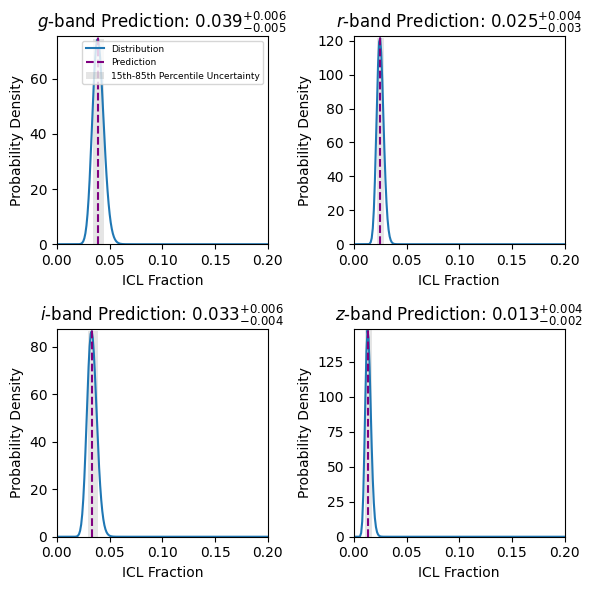

Mean prediction is 0.06006006006006006


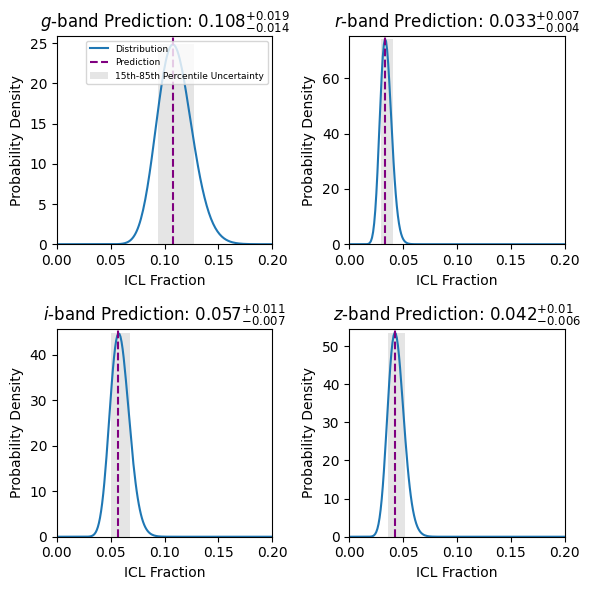

Mean prediction is 0.057057057057057055


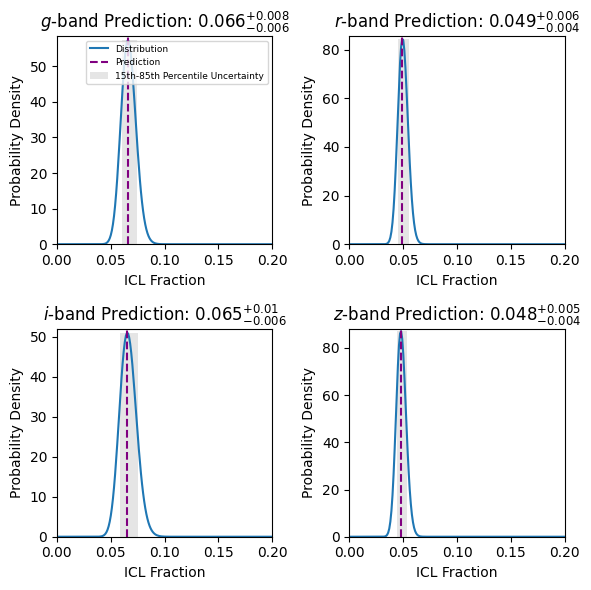

Mean prediction is 0.03178178178178178


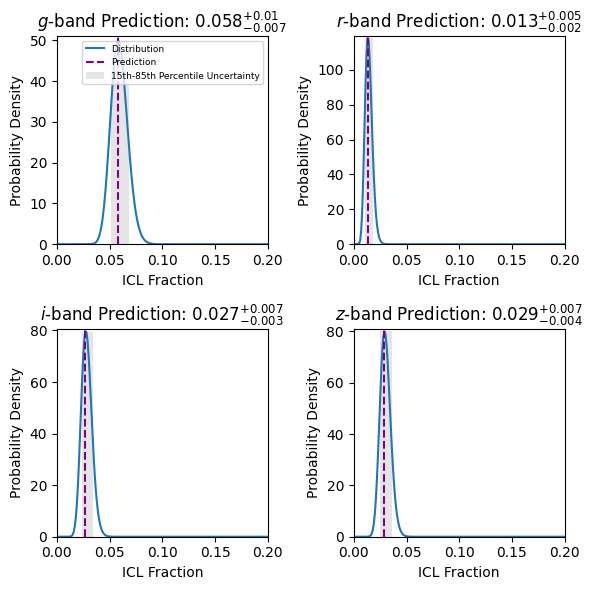

Mean prediction is 0.039039039039039033


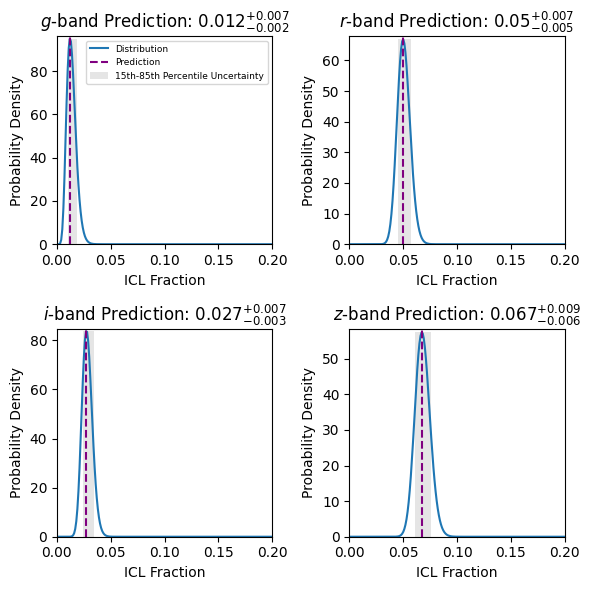

Mean prediction is 0.02977977977977978


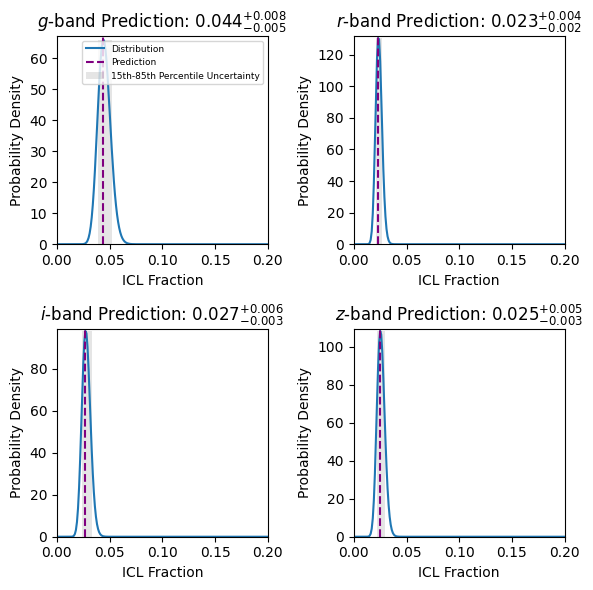

Mean prediction is 0.023273273273273273


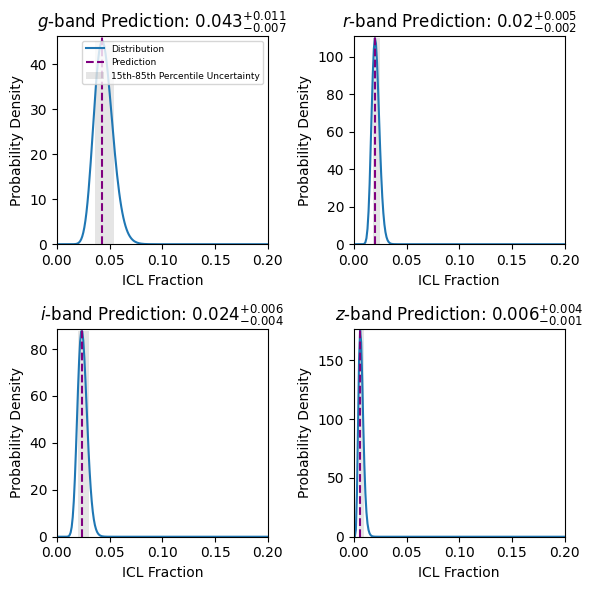

Mean prediction is 0.0578078078078078


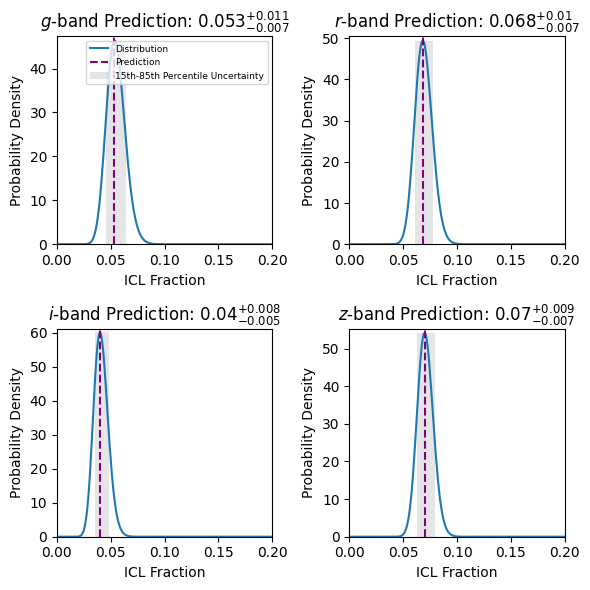

Mean prediction is 0.028778778778778775


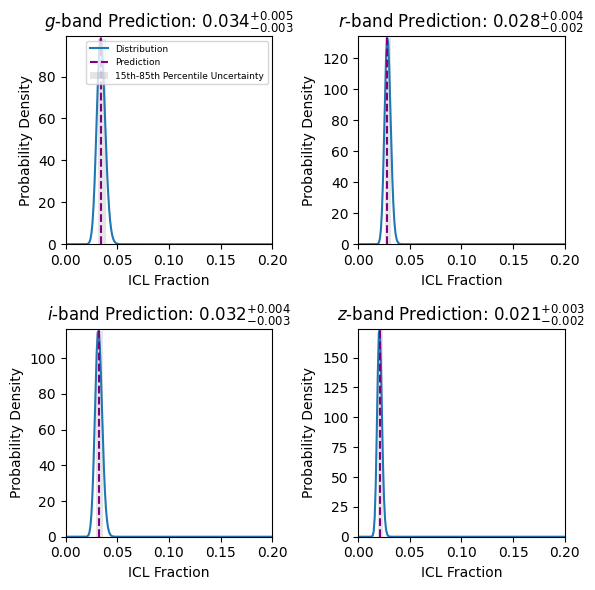

Mean prediction is 0.04204204204204204


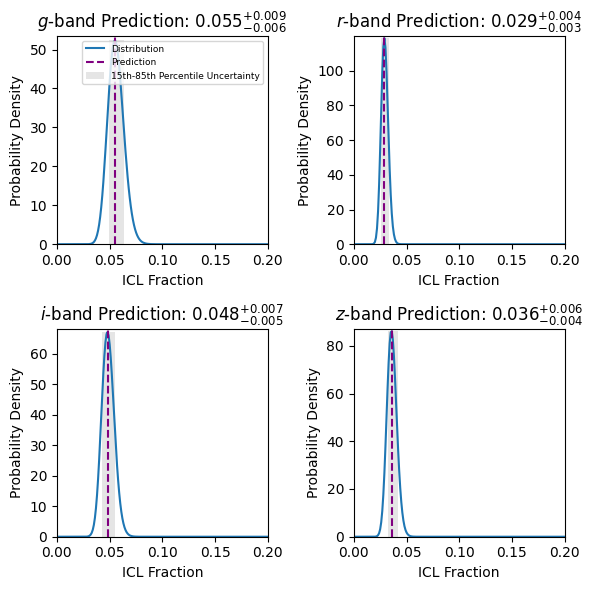

Mean prediction is 0.043043043043043044


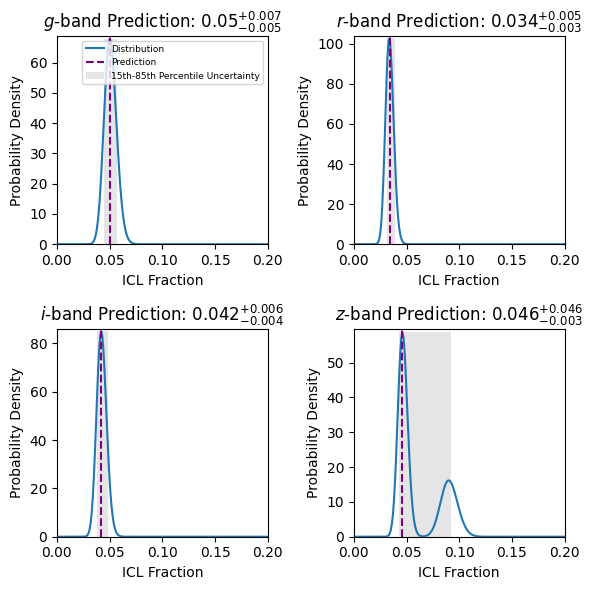

Mean prediction is 0.02052052052052052


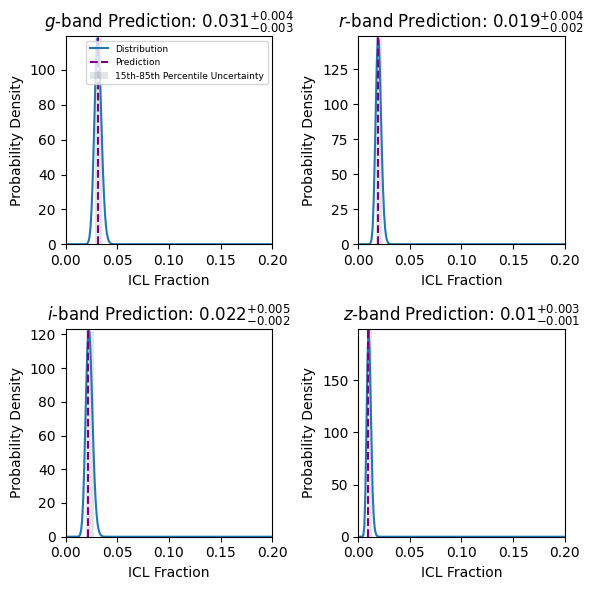

Mean prediction is 0.056056056056056056


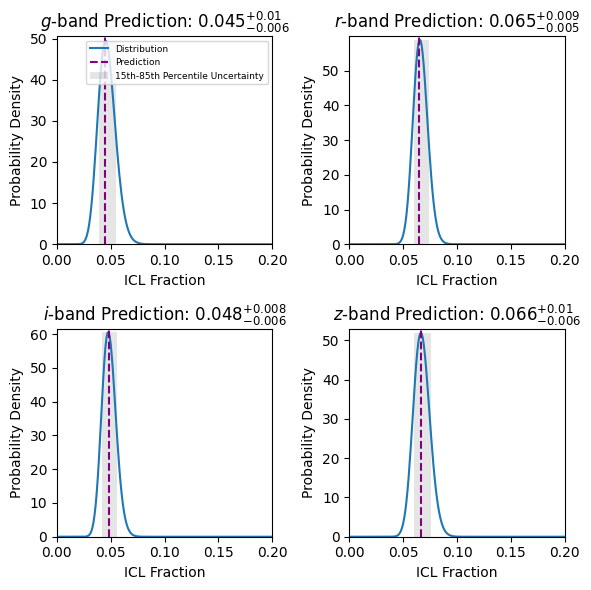

Mean prediction is 0.029029029029029027


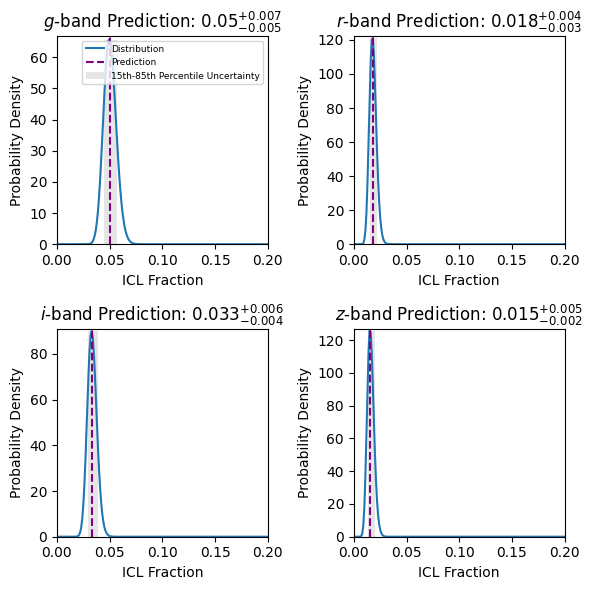

Mean prediction is 0.03653653653653654


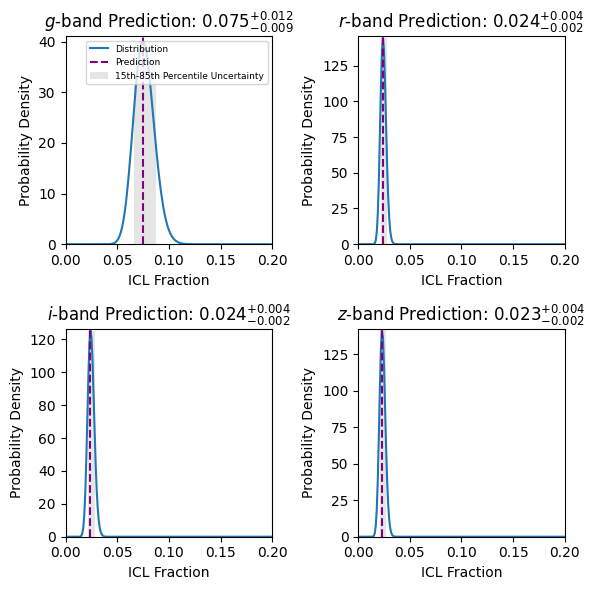

Mean prediction is 0.026026026026026026


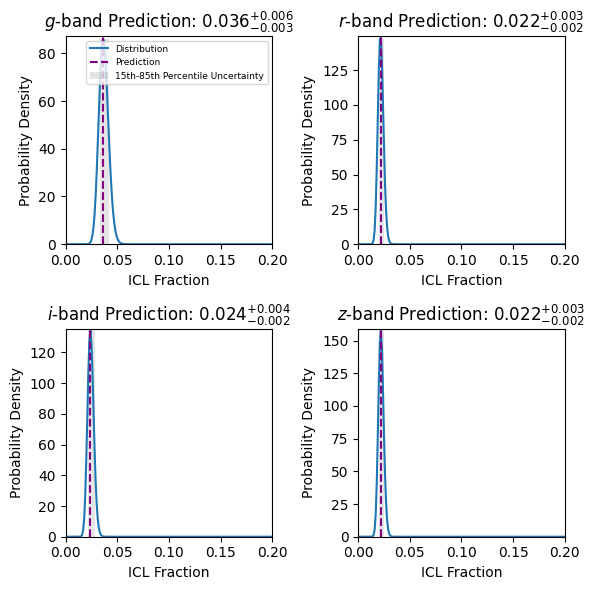

Mean prediction is 0.02727727727727728


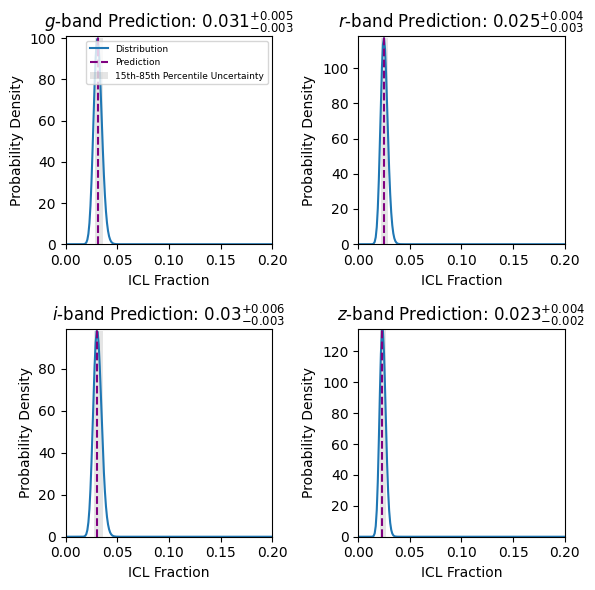

Mean prediction is 0.024274274274274275


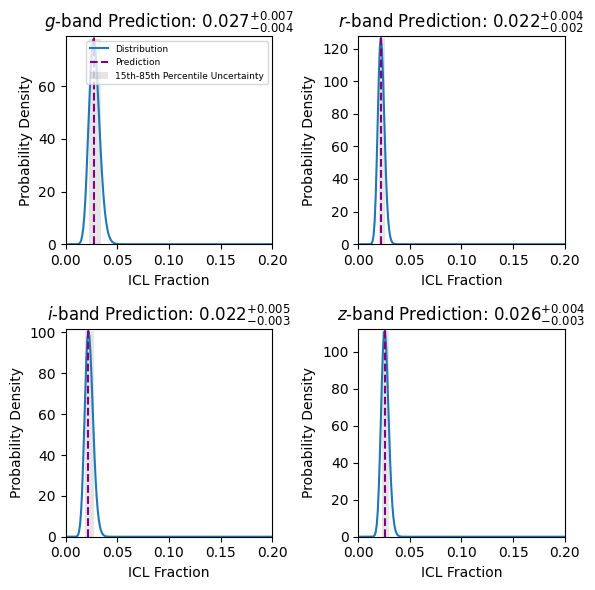

In [3]:
cluster_list = ['A3911','A2597','A4059','A4010','A1651',
                'A1307','A3921','RBS1847','A2811','A2721',
                'A1650','A3158','A458','A3266','A3112',
                'A3822','A2029','A3571']
band_dict = {"g": 0, "r": 1, "i": 2, "z": 3}

fraction_list = []

for cln in cluster_list:
    cutouts = f'../{cln}_input_cutouts.h5'
    images = []

    csv_row = [cln] #Add cln as first row


    with h5py.File(cutouts, 'r') as hf:
        for key in hf.keys():
            img = np.array(hf[key]['DATA'])
            mask = np.array(hf[key]['MASK'])

            # Scale the images and apply the mask
            img = np.clip(img, a_min=0, a_max=10)
            img = np.arcsinh(img / 0.017359) 
            img = img * ~(mask > 0)

            # Place into array
            img = np.expand_dims(img, -1) # Reshape the array to (224, 224, 1)
            images.append(img)

    data = np.array(images) 

    outputs = model(data)


    x = np.linspace(0, 1, 1000) # Need to define where we evaluate all the distributions
    dists = outputs.distribution.prob(x) # Get all the output probability distributions as arrays
    predictions = x[np.argmax(dists, axis=1)] # Find the peaks of the distributions
    cdfs = outputs.distribution.cdf(x) # Get the CDFs

    # Get the 15 and 85 percentile uncertainties
    q15s = np.argmax(cdfs >= 0.15, axis=1)
    q85s = np.argmax(cdfs >= 0.85, axis=1)
    lower_errors = np.abs(predictions - x[q15s])
    upper_errors = np.abs(x[q85s] - predictions)

    print(f'Mean prediction is {np.mean(predictions)}')

    fig, axes = plt.subplots(2, 2, figsize=(6, 6))
    axes = axes.flatten()


    for i, band in enumerate(band_dict):
        example_dist = dists[band_dict[band]]
        prediction = predictions[band_dict[band]]
        q15 = q15s[band_dict[band]]
        q85 = q85s[band_dict[band]]

        # Save fraction to csv list

        csv_row.append(prediction)
        csv_row.append(lower_errors[i])
        csv_row.append(upper_errors[i])

        # Single plot figures
        plt.figure()
        plt.plot(x, example_dist)
        plt.axvline(prediction, c='purple', linestyle='--')
        plt.fill_between([x[q15], x[q85]], min(example_dist), max(example_dist), facecolor='gray', alpha=0.2)
        plt.xlim(0, 0.2)
        plt.ylim(0, max(example_dist) + 1)
        plt.xlabel('ICL Fraction')
        plt.ylabel('Probability Density')
        plt.legend(['Distribution', 'Prediction', '15th-85th Percentile Uncertainty'])
        plt.title(fr'{cln} ${band}$-band Prediction:'+str(round(prediction,3))+'$^{+'+str(round(upper_errors[i], 3))+'}_{-'+str(round(lower_errors[i],3))+'}$')
        plt.tight_layout()
        plt.savefig(f'{cln}_{band}_micl_frac.png', dpi=1000, bbox_inches='tight')
        # plt.show()
        plt.close()



        # Put the plots in a grid
        ax = axes[i]
        ax.plot(x, example_dist)
        ax.axvline(prediction, c='purple', linestyle='--')
        ax.fill_between([x[q15], x[q85]], min(example_dist), max(example_dist), facecolor='gray', alpha=0.2)
        ax.set_xlim(0, 0.2)
        ax.set_ylim(0, max(example_dist) + 1)
        ax.set_xlabel('ICL Fraction')
        ax.set_ylabel('Probability Density')
        if i == 0:
            ax.legend(['Distribution', 'Prediction', '15th-85th Percentile Uncertainty'],
                        fontsize=6.5, loc='upper right', frameon=True)
        ax.set_title(fr'${band}$-band Prediction: '+str(round(prediction,3))+'$^{+'+str(round(upper_errors[i], 3))+'}_{-'+str(round(lower_errors[i],3))+'}$')
    plt.tight_layout()
    plt.savefig(f'{cln}_micl_frac_grid.png', dpi=1000, bbox_inches='tight')
    plt.show()

    fraction_list.append(csv_row) #append cln fractions to csv


with open('micl_fractions.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    
    writer.writerow(['Name'] + 
                    ["g_icl_frac", "g_icl_frac_15th_per", "g_icl_frac_85th_per",
                     "r_icl_frac", "r_icl_frac_15th_per", "r_icl_frac_85th_per",
                     "i_icl_frac", "i_icl_frac_15th_per", "i_icl_frac_85th_per",
                     "z_icl_frac", "z_icl_frac_15th_per", "z_icl_frac_85th_per"])
    
    # Write all rows
    writer.writerows(fraction_list)